In [1]:
# Cell 1: Imports and Database Connection
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Paths
db_path = "../data/db/bluestock_mf.db"
output_dir = "../reports/charts"
processed_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

# Connect to DB
conn = sqlite3.connect(db_path)

# Pull daily NAV history
query = """
    SELECT date, amfi_code, nav 
    FROM fact_nav 
    ORDER BY amfi_code, date;
"""
df_nav = pd.read_sql_query(query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
conn.close()

print(f"Loaded {len(df_nav)} daily NAV rows for processing.")

Loaded 71960 daily NAV rows for processing.


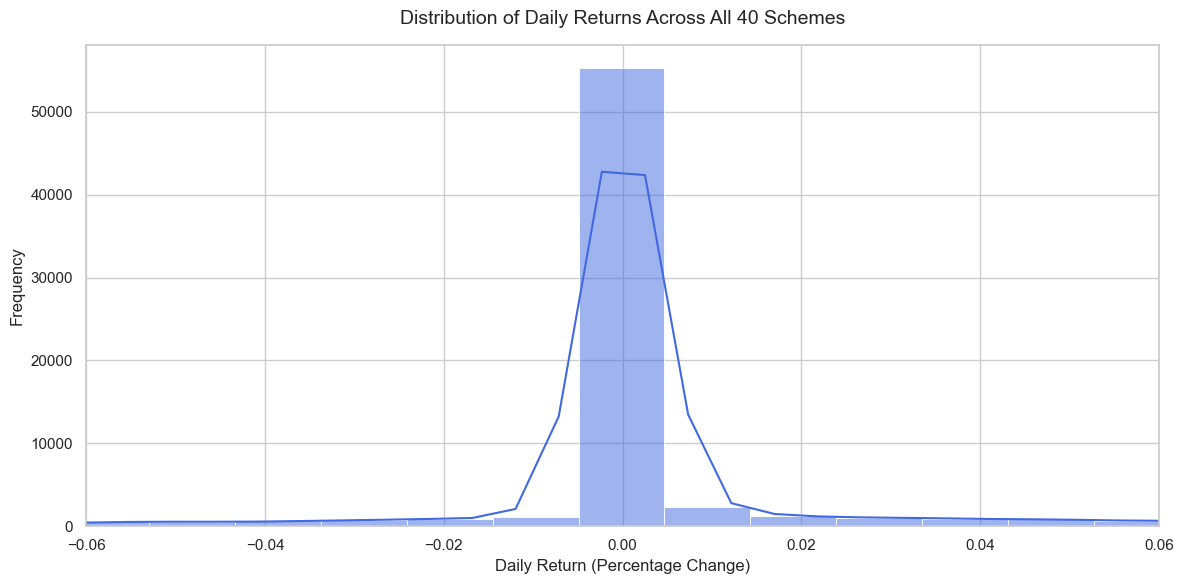

Daily returns calculated. Check the plot above to verify the bell curve distribution.


In [2]:
# Cell 2: Compute Daily Returns & Plot Distribution
# Calculate daily returns per scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Drop the first row of each group since its return will be NaN
df_returns_cleaned = df_nav.dropna(subset=['daily_return'])

# Plotting the distribution to validate
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot aggregate return distribution across all 40 schemes
sns.histplot(df_returns_cleaned['daily_return'], bins=100, kde=True, color='royalblue')

plt.title('Distribution of Daily Returns Across All 40 Schemes', fontsize=14, pad=15)
plt.xlabel('Daily Return (Percentage Change)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Set limits to trim extreme outliers visually if needed
plt.xlim(-0.06, 0.06) 

plt.tight_layout()
plt.show()

print("Daily returns calculated. Check the plot above to verify the bell curve distribution.")

In [3]:
# Cell 3: Compute CAGR Comparison Table
def calculate_cagr(df_group, years):
    # Find the latest available date for this group
    latest_date = df_group['date'].max()
    target_date = latest_date - pd.DateOffset(years=years)
    
    # Get the latest NAV
    nav_end = df_group[df_group['date'] == latest_date]['nav'].values[0]
    
    # Find the closest available date to our target historic date
    historic_data = df_group[df_group['date'] <= target_date]
    if historic_data.empty:
        return np.nan # Not enough historic data for this timeframe
        
    closest_row = historic_data.sort_values(by='date', ascending=False).iloc[0]
    nav_start = closest_row['nav']
    
    # Calculate actual fraction of years between dates for precision
    actual_days = (latest_date - closest_row['date']).days
    n = actual_days / 365.25
    
    if n <= 0 or nav_start <= 0:
        return np.nan
        
    return (nav_end / nav_start) ** (1 / n) - 1

# List to compile records
cagr_records = []

# Group by fund and calculate
for amfi_code, group in df_nav.groupby('amfi_code'):
    group_sorted = group.sort_values('date')
    
    cagr_1yr = calculate_cagr(group_sorted, 1)
    cagr_3yr = calculate_cagr(group_sorted, 3)
    cagr_5yr = calculate_cagr(group_sorted, 5)
    
    cagr_records.append({
        'amfi_code': amfi_code,
        'cagr_1yr_pct': cagr_1yr * 100 if not pd.isna(cagr_1yr) else np.nan,
        'cagr_3yr_pct': cagr_3yr * 100 if not pd.isna(cagr_3yr) else np.nan,
        'cagr_5yr_pct': cagr_5yr * 100 if not pd.isna(cagr_5yr) else np.nan
    })

# Convert to DataFrame
df_cagr = pd.DataFrame(cagr_records)

# Display a preview of the comparison table sorted by 3-year performance
print("--- CAGR Comparison Table Preview (Top 5 by 3yr Return) ---")
print(df_cagr.sort_values(by='cagr_3yr_pct', ascending=False).head().to_string(index=False))

--- CAGR Comparison Table Preview (Top 5 by 3yr Return) ---
 amfi_code  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
    148567     27.014496     37.455413           NaN
    120505     32.665955     34.708046           NaN
    119094     20.099220     33.531808           NaN
    120843     39.174835     32.725271           NaN
    149324     83.925286     32.122681           NaN


In [4]:
# Cell 4: Sharpe and Sortino Ratios Calculation
risk_free_rate = 0.065
rf_daily = risk_free_rate / 252

ratios_records = []

for amfi_code, group in df_nav.groupby('amfi_code'):
    # Ensure no NaNs in returns
    returns = group['daily_return'].dropna()
    
    if len(returns) < 2:
        continue
        
    # Annualized Mean Return
    mean_return_annual = returns.mean() * 252
    
    # Total Annualized Volatility (Standard Deviation)
    std_dev_annual = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio: (Rp_annual - Rf_annual) / Std_dev_annual
    sharpe_ratio = (mean_return_annual - risk_free_rate) / std_dev_annual if std_dev_annual > 0 else np.nan
    
    # Downside Volatility: Standard deviation of negative return days only
    negative_returns = returns[returns < 0]
    if len(negative_returns) > 1:
        # Standard financial practice uses root-mean-square of negative returns or standard deviation
        downside_std_annual = negative_returns.std() * np.sqrt(252)
        sortino_ratio = (mean_return_annual - risk_free_rate) / downside_std_annual if downside_std_annual > 0 else np.nan
    else:
        sortino_ratio = np.nan
        
    ratios_records.append({
        'amfi_code': amfi_code,
        'annualized_return': mean_return_annual * 100,
        'annualized_volatility': std_dev_annual * 100,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio
    })

df_ratios = pd.DataFrame(ratios_records)

# Rank funds based on Sharpe Ratio
df_ratios['sharpe_rank'] = df_ratios['sharpe_ratio'].rank(ascending=False, method='min')
df_ratios['sortino_rank'] = df_ratios['sortino_ratio'].rank(ascending=False, method='min')

print("--- Risk-Adjusted Ratios Preview (Top 5 Ranked by Sharpe) ---")
print(df_ratios.sort_values(by='sharpe_rank').head().to_string(index=False))

--- Risk-Adjusted Ratios Preview (Top 5 Ranked by Sharpe) ---
 amfi_code  annualized_return  annualized_volatility  sharpe_ratio  sortino_ratio  sharpe_rank  sortino_rank
    149324          78.527045             102.673722      0.701514       0.425362          1.0           2.0
    119598          67.007609              99.034672      0.610974       0.430052          2.0           1.0
    120843          57.883967              85.632071      0.600055       0.327032          3.0           4.0
    120505          57.346383              86.553785      0.587454       0.315413          4.0           7.0
    148567          53.036621              79.737057      0.583626       0.244094          5.0          14.0


In [8]:
# Cell 5 (FIXED): Alpha and Beta Calculation via OLS Regression
from scipy.stats import linregress

benchmark_path = "../data/raw/10_benchmark_indices.csv"
market_returns = None

try:
    # 1. Load the benchmark index file
    df_bench = pd.read_csv(benchmark_path)
    print("Columns found in benchmark dataset:", df_bench.columns.tolist())
    
    # Filter for Nifty 100 if there are multiple indices stacked in the file
    if 'index_name' in df_bench.columns:
        nifty100_mask = df_bench['index_name'].str.contains('100', case=False, na=False)
        if nifty100_mask.any():
            df_bench = df_bench[nifty100_mask]
            print("  -> Filtered specifically for Nifty 100 index rows.")
    
    # Parse dates and sort chronologically (crucial before pct_change!)
    df_bench['parsed_date'] = pd.to_datetime(df_bench['date'])
    df_bench = df_bench.sort_values('parsed_date')
    
    # Calculate daily return from the close_value
    df_bench['market_return'] = df_bench['close_value'].pct_change()
        
    market_returns = df_bench.set_index('parsed_date')['market_return'].dropna()
    print("✅ Successfully loaded and parsed true benchmark returns!")

except Exception as e:
    print(f"⚠️ Error parsing true benchmark index ({e}). Falling back to proxy...")
    market_returns = df_returns_cleaned.groupby('date')['daily_return'].mean()

# 2. Compute Alpha & Beta per fund
alpha_beta_records = []

for amfi_code, group in df_returns_cleaned.groupby('amfi_code'):
    fund_series = group.set_index('date')['daily_return'].dropna()
    aligned_data = pd.concat([fund_series, market_returns], axis=1, join='inner').dropna()
    aligned_data.columns = ['fund', 'market']
    
    if len(aligned_data) < 10:
        continue
        
    # Run OLS Regression
    slope, intercept, r_value, p_value, std_err = linregress(aligned_data['market'], aligned_data['fund'])
    
    # Annualize Alpha (intercept * 252)
    annualized_alpha = intercept * 252
    beta = slope
    
    alpha_beta_records.append({
        'amfi_code': amfi_code,
        'alpha': annualized_alpha,
        'beta': beta,
        'r_squared': r_value ** 2
    })

df_alpha_beta = pd.DataFrame(alpha_beta_records)

# Save to processed directory
df_alpha_beta.to_csv(f"{processed_dir}/alpha_beta.csv", index=False)

print("\n--- Alpha and Beta Preview (Top 5 by Alpha) ---")
print(df_alpha_beta.sort_values(by='alpha', ascending=False).head().to_string(index=False))
print(f"✅ Saved alpha_beta.csv to {processed_dir}")

Columns found in benchmark dataset: ['date', 'index_name', 'close_value']
  -> Filtered specifically for Nifty 100 index rows.
✅ Successfully loaded and parsed true benchmark returns!

--- Alpha and Beta Preview (Top 5 by Alpha) ---
 amfi_code    alpha      beta  r_squared
    149324 1.049289 -0.198529   0.000620
    120843 0.601833 -0.236245   0.001146
    148567 0.589724  0.176022   0.000739
    119551 0.579338 -0.231185   0.001939
    148569 0.558991 -0.103258   0.000307
✅ Saved alpha_beta.csv to ../data/processed


In [9]:
# Cell 6: Maximum Drawdown & Date Ranges
import sqlite3
import pandas as pd

drawdown_records = []

for amfi_code, group in df_nav.groupby('amfi_code'):
    # 1. Ensure data is chronologically sorted
    fund_data = group.sort_values('date').copy()
    
    # 2. Calculate the running maximum NAV up to each date
    fund_data['running_max'] = fund_data['nav'].cummax()
    
    # 3. Calculate the percentage drawdown from the running max
    fund_data['drawdown'] = (fund_data['nav'] / fund_data['running_max']) - 1
    
    # 4. Find the Maximum Drawdown (the lowest negative number)
    max_dd = fund_data['drawdown'].min()
    
    if pd.isna(max_dd) or max_dd == 0:
        drawdown_records.append({
            'amfi_code': amfi_code,
            'max_drawdown_pct': 0,
            'peak_date': None,
            'trough_date': None
        })
        continue
        
    # 5. Identify the exact Trough Date
    trough_idx = fund_data['drawdown'].idxmin()
    trough_date = fund_data.loc[trough_idx, 'date']
    
    # 6. Trace back to find the exact Peak Date that preceded this trough
    peak_nav_value = fund_data.loc[trough_idx, 'running_max']
    pre_trough_data = fund_data[fund_data['date'] <= trough_date]
    peak_date = pre_trough_data[pre_trough_data['nav'] == peak_nav_value]['date'].iloc[-1]
    
    drawdown_records.append({
        'amfi_code': amfi_code,
        'max_drawdown_pct': max_dd * 100, # Convert to percentage
        'peak_date': peak_date.strftime('%Y-%m-%d'),
        'trough_date': trough_date.strftime('%Y-%m-%d')
    })

# Convert to DataFrame
df_drawdown = pd.DataFrame(drawdown_records)

# Let's quickly pull scheme names from the DB to make our printout readable
conn = sqlite3.connect(db_path)
df_names = pd.read_sql_query("SELECT amfi_code, scheme_name FROM dim_fund", conn)
conn.close()

# Merge and preview the worst drawdowns
df_drawdown_display = df_drawdown.merge(df_names, on='amfi_code', how='left')

print("--- Maximum Drawdown Preview (Top 5 Worst Drops) ---")
# Sorting ascending because drawdowns are negative numbers (e.g., -35% is worse than -10%)
print(df_drawdown_display[['scheme_name', 'max_drawdown_pct', 'peak_date', 'trough_date']]
      .sort_values(by='max_drawdown_pct', ascending=True)
      .head().to_string(index=False))

--- Maximum Drawdown Preview (Top 5 Worst Drops) ---
                               scheme_name  max_drawdown_pct  peak_date trough_date
     DSP Small Cap Fund - Regular - Growth        -52.352599 2025-02-28  2025-03-01
    Axis Small Cap Fund - Regular - Growth        -49.842196 2025-08-06  2026-11-05
 SBI Small Cap Fund - Direct Plan - Growth        -49.737160 2023-11-03  2025-10-10
SBI Small Cap Fund - Regular Plan - Growth        -43.390783 2023-03-10  2023-10-01
        DSP Midcap Fund - Regular - Growth        -42.869999 2023-02-10  2023-10-02


In [10]:
# Cell 7: Quantitative Fund Scorecard (0-100)
import pandas as pd
import sqlite3

# 1. Fetch Expense Ratios and Scheme Names from DB
conn = sqlite3.connect(db_path)
df_fund_info = pd.read_sql_query("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)
conn.close()

# 2. Merge all our calculated metrics into one master DataFrame
df_master = df_fund_info.merge(df_cagr[['amfi_code', 'cagr_3yr_pct']], on='amfi_code', how='left')
df_master = df_master.merge(df_ratios[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
df_master = df_master.merge(df_alpha_beta[['amfi_code', 'alpha']], on='amfi_code', how='left')
df_master = df_master.merge(df_drawdown[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left')

# Drop any funds that don't have enough history for a 3-year return or valid metrics
df_master = df_master.dropna().copy()

# 3. Calculate Percentile Scores (0 to 100) for each metric
# rank(pct=True) gives a value from 0.0 to 1.0. We multiply by 100.
df_master['score_3yr'] = df_master['cagr_3yr_pct'].rank(ascending=True, pct=True) * 100
df_master['score_sharpe'] = df_master['sharpe_ratio'].rank(ascending=True, pct=True) * 100
df_master['score_alpha'] = df_master['alpha'].rank(ascending=True, pct=True) * 100

# Inverse rankings (Lower expense is better. Less severe drawdown is better)
df_master['score_expense'] = df_master['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
df_master['score_drawdown'] = df_master['max_drawdown_pct'].rank(ascending=True, pct=True) * 100

# 4. Calculate Final Composite Score
df_master['composite_score'] = (
    (df_master['score_3yr'] * 0.30) +
    (df_master['score_sharpe'] * 0.25) +
    (df_master['score_alpha'] * 0.20) +
    (df_master['score_expense'] * 0.15) +
    (df_master['score_drawdown'] * 0.10)
)

# 5. Sort by Best Score and clean up the final presentation
df_scorecard = df_master.sort_values(by='composite_score', ascending=False).round(2)

# Save to processed directory
df_scorecard.to_csv(f"{processed_dir}/fund_scorecard.csv", index=False)

print("--- The Final Fund Scorecard (Top 5 Elite Funds) ---")
cols_to_show = ['scheme_name', 'composite_score', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct']
print(df_scorecard[cols_to_show].head().to_string(index=False))
print(f"\n✅ Saved fund_scorecard.csv to {processed_dir}")

--- The Final Fund Scorecard (Top 5 Elite Funds) ---
                                  scheme_name  composite_score  cagr_3yr_pct  sharpe_ratio  alpha  expense_ratio_pct
       Kotak Flexicap Fund - Regular - Growth            80.62         32.73          0.60   0.60               1.45
Mirae Asset Large Cap Fund - Regular - Growth            79.75         37.46          0.58   0.59               1.46
     ICICI Pru Midcap Fund - Regular - Growth            79.62         34.71          0.59   0.50               1.36
        DSP Small Cap Fund - Regular - Growth            77.69         32.12          0.70   1.05               1.52
          Axis Midcap Fund - Regular - Growth            77.50         33.53          0.56   0.54               1.38

✅ Saved fund_scorecard.csv to ../data/processed


--- Tracking Error (Top 5 Funds vs Nifty 100) ---
Kotak Flexicap Fund - Regular       | Tracking Error: 93.99%
Mirae Asset Large Cap Fund - R      | Tracking Error: 98.47%
ICICI Pru Midcap Fund - Regula      | Tracking Error: 69.91%
DSP Small Cap Fund - Regular -      | Tracking Error: 117.65%
Axis Midcap Fund - Regular - G      | Tracking Error: 92.86%


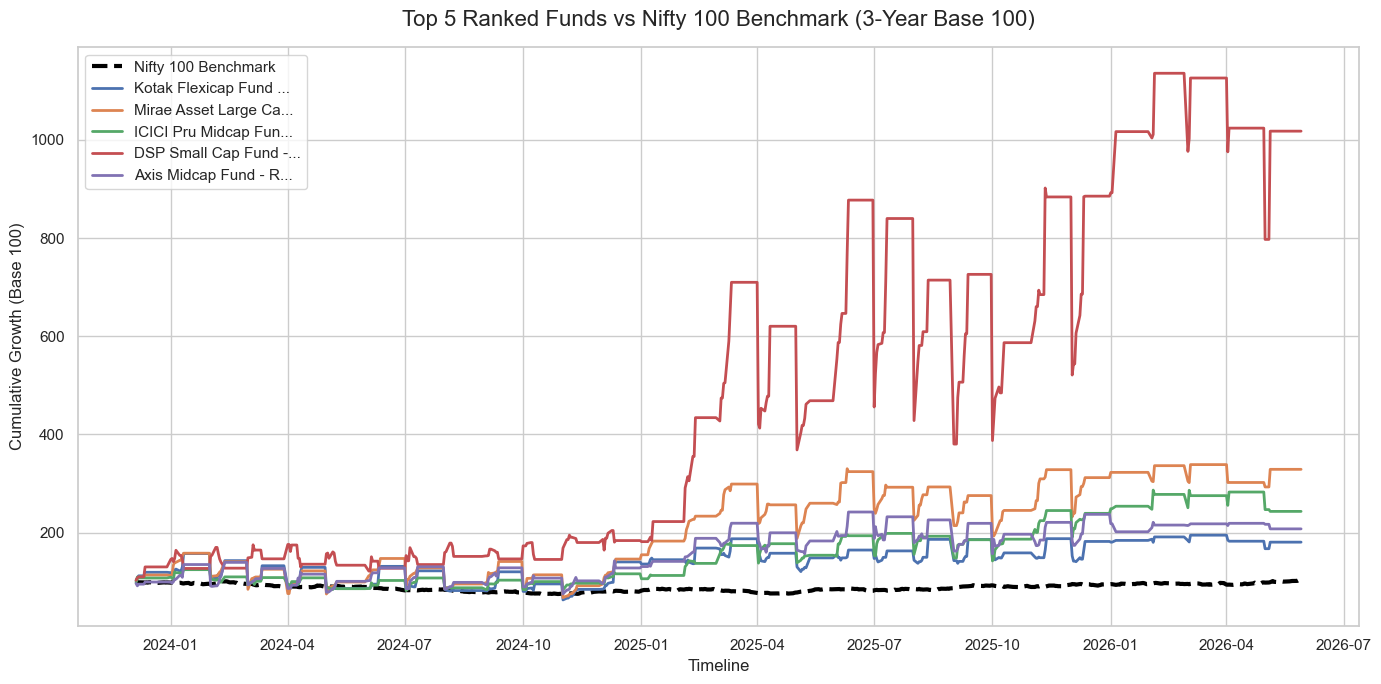


✅ Saved 10_benchmark_comparison.png to ../reports/charts


In [11]:
# Cell 8: Benchmark Comparison & Tracking Error (Top 5 Funds vs Market)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Identify Top 5 Funds from our Scorecard
top_5_amfi = df_scorecard['amfi_code'].head(5).tolist()

# 2. Filter daily returns for Top 5 over the last 3 years
# Using the market_returns series we built in Cell 5
latest_date = df_returns_cleaned['date'].max()
start_date_3yr = latest_date - pd.DateOffset(years=3)

df_top5_returns = df_returns_cleaned[
    (df_returns_cleaned['amfi_code'].isin(top_5_amfi)) & 
    (df_returns_cleaned['date'] >= start_date_3yr)
].copy()

# 3. Align with Market Returns and compute Tracking Error
print("--- Tracking Error (Top 5 Funds vs Nifty 100) ---")
tracking_errors = []

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot the Benchmark First (Base 100)
market_3yr = market_returns[market_returns.index >= start_date_3yr].copy()
market_cumulative = (1 + market_3yr).cumprod() * 100
plt.plot(market_cumulative.index, market_cumulative, label='Nifty 100 Benchmark', color='black', linewidth=3, linestyle='--')

# Plot each Top 5 Fund and calculate TE
for amfi_code in top_5_amfi:
    fund_name = df_scorecard[df_scorecard['amfi_code'] == amfi_code]['scheme_name'].values[0]
    
    # Isolate fund daily returns
    f_returns = df_top5_returns[df_top5_returns['amfi_code'] == amfi_code].set_index('date')['daily_return']
    
    # Align exact dates
    aligned = pd.concat([f_returns, market_3yr], axis=1, join='inner').dropna()
    aligned.columns = ['fund', 'market']
    
    # Tracking Error: StdDev of (Fund Return - Market Return) * sqrt(252)
    active_returns = aligned['fund'] - aligned['market']
    te = active_returns.std() * np.sqrt(252)
    
    print(f"{fund_name[:30]:<35} | Tracking Error: {te*100:.2f}%")
    
    # Cumulative Return for plotting (Base 100)
    fund_cumulative = (1 + aligned['fund']).cumprod() * 100
    plt.plot(fund_cumulative.index, fund_cumulative, label=f"{fund_name[:20]}...", linewidth=2)

# 4. Chart Formatting
plt.title('Top 5 Ranked Funds vs Nifty 100 Benchmark (3-Year Base 100)', fontsize=16, pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Cumulative Growth (Base 100)', fontsize=12)
plt.legend(loc='upper left')

# Save and Show
plt.tight_layout()
plt.savefig(f"{output_dir}/10_benchmark_comparison.png", dpi=300)
plt.show()

print(f"\n✅ Saved 10_benchmark_comparison.png to {output_dir}")